# Customer Churn Prediction — Step 4: Exploratory Data Analysis (EDA)

**Dataset:** `data/telco_churn_cleaned.csv` — produced by Step 3 (Data Cleaning)  
**Input:** cleaned CSV (7,021 rows × 20 columns, `customerID` dropped, `TotalCharges` is `float64`)  

### What this notebook does
Explores the structure, distributions, and relationships in the cleaned dataset to inform feature selection and model strategy.  
Every section explains what is being measured **before** the code runs, and every important visualisation is followed by a written interpretation.

### What this notebook does NOT do
- Does **not** train any machine learning model.
- Does **not** perform feature encoding, scaling, or any transformation.
- Does **not** modify or re-save the cleaned dataset.

---

## 1. Setup — Import Libraries and Load Cleaned Data

We import `pandas` for data handling, `matplotlib` and `seaborn` for visualisation, and `numpy` for minor numeric utilities.  
Seaborn's default theme is applied globally for consistent, readable plots throughout this notebook.  

We load `telco_churn_cleaned.csv` — the file produced at the end of Step 3 — and immediately confirm its shape and that no missing values are present.

In [22]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Global plot style ─────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# ── Resolve paths ─────────────────────────────────────────────────────────────
NOTEBOOK_DIR = os.path.abspath('')
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR) if os.path.basename(NOTEBOOK_DIR) == 'notebook' else NOTEBOOK_DIR
CLEAN_PATH   = os.path.join(PROJECT_ROOT, 'data', 'telco_churn_cleaned.csv')

print('Cleaned data path:', CLEAN_PATH)
print('File exists:', os.path.exists(CLEAN_PATH))

Cleaned data path: c:\Users\Subham\OneDrive\Documents\Desktop\Customer_Churn_Project\data\telco_churn_cleaned.csv
File exists: True


In [23]:
# Load cleaned dataset — read-only in this notebook
df = pd.read_csv(CLEAN_PATH)

print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Missing values: {df.isnull().sum().sum()}')

Loaded: 7,021 rows × 20 columns
Missing values: 0


---
## 2. Dataset Overview

Before any visualisation, we take a structured look at the data:  
- **Shape** — confirms row and column counts.  
- **Data types** — identifies which columns are numeric and which are categorical (object).  
- **Numerical summary** — `describe()` gives min, max, mean, quartiles for all numeric columns.  
- **Categorical columns** — for each `object` column, we print unique value counts to understand cardinality and spot any unexpected values.

In [24]:
print('=== Shape ===')
print(f'{df.shape[0]:,} rows × {df.shape[1]} columns\n')

print('=== Data types ===')
print(df.dtypes.to_string())

=== Shape ===
7,021 rows × 20 columns

=== Data types ===
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object


In [25]:
print('=== Numerical summary ===')
display(df.describe(include=[np.number]).T)

=== Numerical summary ===


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7021.0,0.162512,0.368947,0.00,0.00,0.00,0.0,1.00
tenure,7021.0,32.469449,24.534965,0.00,9.00,29.00,55.0,72.00
MonthlyCharges,7021.0,64.851894,30.069001,18.25,35.75,70.40,89.9,118.75
TotalCharges,7021.0,2286.765026,2266.855057,0.00,403.35,1400.55,3801.7,8684.80


In [26]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}\n')

for col in cat_cols:
    vc = df[col].value_counts()
    print(f'--- {col} ({df[col].nunique()} unique values) ---')
    print(vc.to_string())
    print()

Categorical columns (16): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

--- gender (2 unique values) ---
gender
Male      3541
Female    3480

--- Partner (2 unique values) ---
Partner
No     3619
Yes    3402

--- Dependents (2 unique values) ---
Dependents
No     4911
Yes    2110

--- PhoneService (2 unique values) ---
PhoneService
Yes    6339
No      682

--- MultipleLines (3 unique values) ---
MultipleLines
No                  3368
Yes                 2971
No phone service     682

--- InternetService (3 unique values) ---
InternetService
Fiber optic    3090
DSL            2419
No             1512

--- OnlineSecurity (3 unique values) ---
OnlineSecurity
No                     3490
Yes                    2019
No internet service    1512

--- OnlineBackup (3 unique values) ---
OnlineB

**Interpretation:**  
- The dataset contains **3 numeric columns** (`SeniorCitizen`, `tenure`, `MonthlyCharges`, `TotalCharges`) and **17 categorical columns** including the target `Churn`.  
- `SeniorCitizen` is stored as `int64` (0/1 binary indicator) — it was kept numeric intentionally (see Step 3).  
- `tenure` ranges from 0 to 72 months. `MonthlyCharges` spans \$18–\$119. `TotalCharges` spans \$0–\$8,685.  
- There are no missing values in the cleaned dataset.  
- Categorical columns have low-to-moderate cardinality (2–4 unique values each), which is ideal for bar-chart analysis.

---
## 3. Target Variable Analysis — Churn

The target variable `Churn` has two values: `'Yes'` (churned) and `'No'` (retained).  
Understanding class balance is essential before any modelling step — a heavily imbalanced target variable affects the choice of algorithm, evaluation metric, and threshold tuning strategy.  

We report:  
1. Raw counts for each class.  
2. Percentage share of each class.  
3. A bar chart showing both absolute counts and percentage annotations.

In [27]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

churn_summary = pd.DataFrame({
    'Count':      churn_counts,
    'Percentage': churn_pct.round(2)
})
print('=== Churn class distribution ===')
display(churn_summary)

=== Churn class distribution ===


,Count,Percentage
Churn,,
No,5164,73.55
Yes,1857,26.45


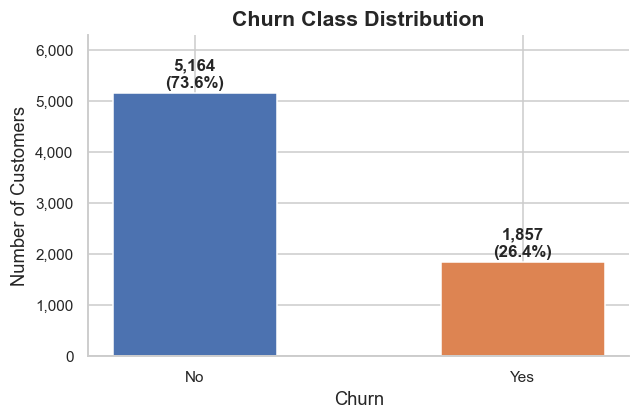

In [28]:
fig, ax = plt.subplots(figsize=(6, 4))

colors = ['#4c72b0', '#dd8452']
bars = ax.bar(churn_counts.index, churn_counts.values, color=colors, width=0.5, edgecolor='white')

# Annotate each bar with count and percentage
for bar, (label, pct) in zip(bars, churn_pct.items()):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 40,
        f'{int(height):,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title('Churn Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.set_ylim(0, churn_counts.max() * 1.22)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()
plt.show()

**Interpretation:**  
The dataset is **moderately imbalanced**: approximately **73.5% of customers did not churn** and **26.5% did churn**.  
This means a naive model that always predicts "No" would achieve ~73.5% accuracy without learning anything useful.  
During modelling (Step 6), this imbalance should be addressed — for example, by using class-weighted loss functions, SMOTE oversampling, or evaluating on precision-recall / ROC-AUC rather than accuracy alone.

---
## 4. Numerical Feature Analysis

We examine the three continuous features: `tenure`, `MonthlyCharges`, and `TotalCharges`.  
For each feature we:  
1. Print summary statistics (mean, median, std, quartiles).  
2. Plot the overall distribution as a histogram with a KDE overlay.  
3. Overlay the distributions split by `Churn` status to reveal whether the feature differs between churned and retained customers.  

No transformations are applied — we observe the raw (cleaned) values only.

In [29]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print('=== Summary statistics for numerical features ===')
display(df[num_cols].describe().T.round(2))

=== Summary statistics for numerical features ===


,count,mean,std,min,25%,50%,75%,max
tenure,7021.0,32.47,24.53,0.00,9.00,29.00,55.0,72.00
MonthlyCharges,7021.0,64.85,30.07,18.25,35.75,70.40,89.9,118.75
TotalCharges,7021.0,2286.77,2266.86,0.00,403.35,1400.55,3801.7,8684.80


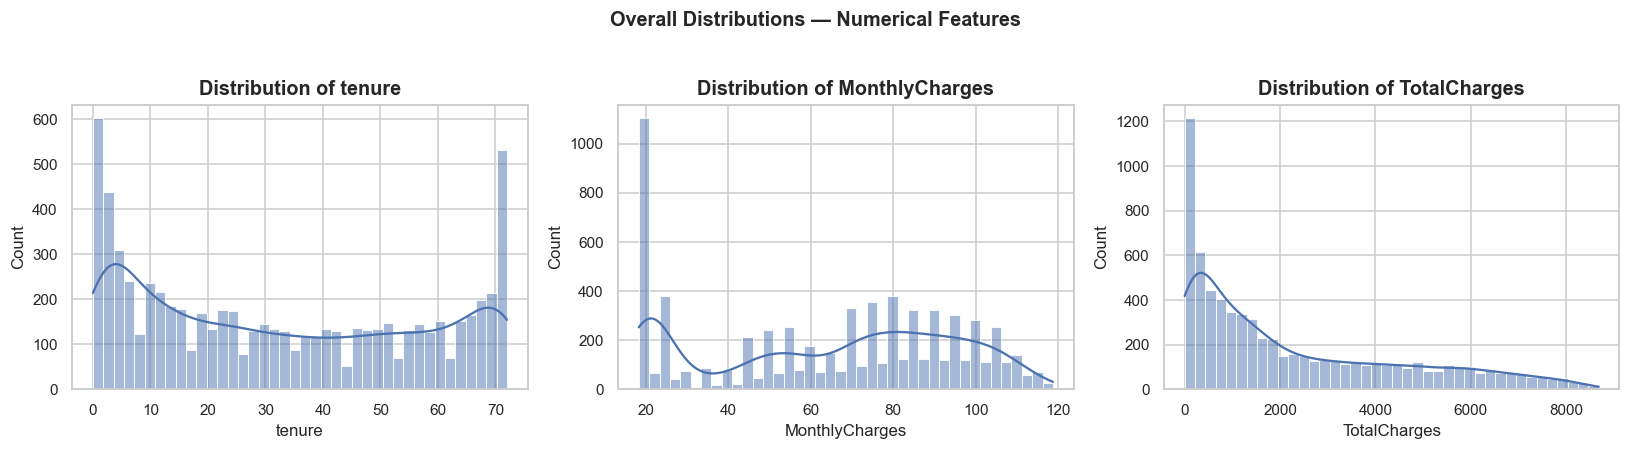

In [30]:
# ── Overall distributions ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color='#4c72b0')
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.suptitle('Overall Distributions — Numerical Features', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

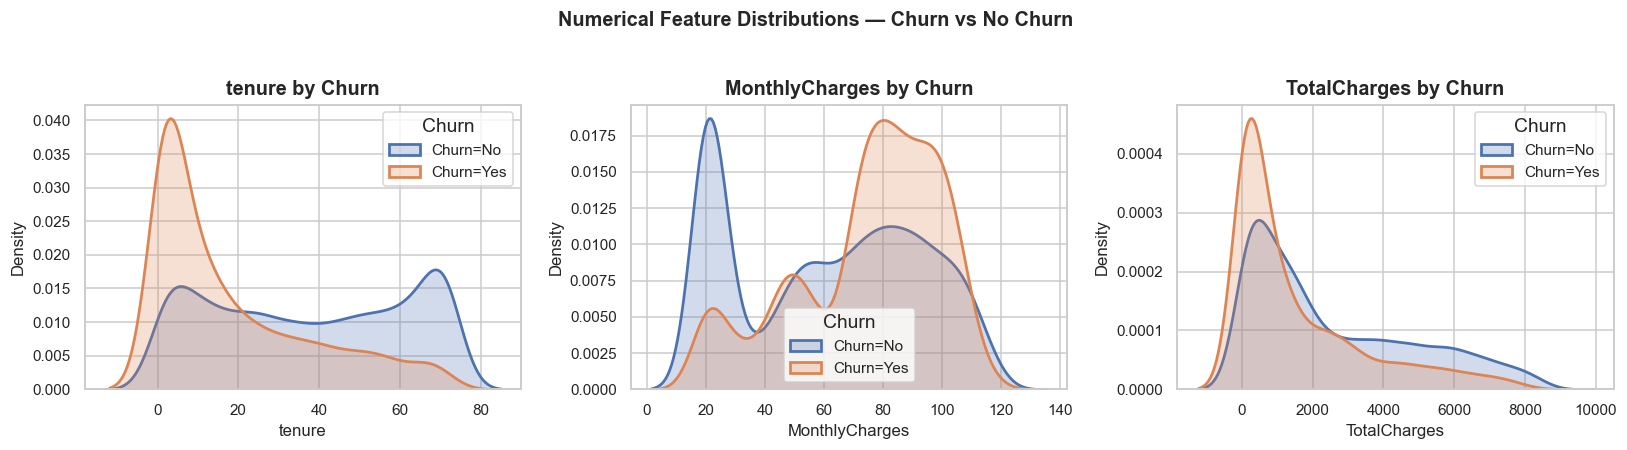

In [31]:
# ── Distributions split by Churn ───────────────────────────────────────────────
palette = {'Yes': '#dd8452', 'No': '#4c72b0'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, num_cols):
    for churn_val, grp in df.groupby('Churn'):
        sns.kdeplot(
            grp[col], ax=ax,
            label=f'Churn={churn_val}',
            color=palette[churn_val],
            fill=True, alpha=0.25, linewidth=1.8
        )
    ax.set_title(f'{col} by Churn', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(title='Churn')

plt.suptitle('Numerical Feature Distributions — Churn vs No Churn', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [32]:
# ── Side-by-side statistics: Churn=Yes vs Churn=No ────────────────────────────
print('=== Numerical features — statistics by Churn group ===')
display(
    df.groupby('Churn')[num_cols]
    .agg(['mean', 'median', 'std'])
    .round(2)
)

=== Numerical features — statistics by Churn group ===


tenure               MonthlyCharges               TotalCharges                 
        mean median    std           mean median    std         mean  median      std
Churn                                                                                
No     37.64   38.0  24.08          61.34   64.5  31.07      2554.81  1683.0  2329.55
Yes    18.09   10.0  19.55          74.60   79.7  24.60      1541.38   713.1  1893.15

**Interpretation — `tenure`:**  
- The tenure distribution is **bimodal**: many customers are either very new (tenure ≈ 0–5 months) or long-tenured (50–72 months).  
- Churned customers are heavily concentrated at **low tenure values** (early months), while retained customers are spread more evenly.  
- The mean tenure for churned customers (~18 months) is substantially lower than for retained customers (~38 months), suggesting that **newer customers show a higher observed churn rate**.  

**Interpretation — `MonthlyCharges`:**  
- The overall distribution is roughly right-skewed with a cluster of low-charge customers (~\$20) and a broad spread up to ~\$119.  
- Churned customers tend to have **higher MonthlyCharges** (mean ~\$74) compared to retained customers (mean ~\$61).  
- This suggests customers on more expensive plans are associated with higher churn — possibly due to cost sensitivity.  

**Interpretation — `TotalCharges`:**  
- `TotalCharges` is strongly right-skewed and closely correlated with `tenure × MonthlyCharges`.  
- Churned customers show **lower TotalCharges** overall, consistent with their shorter tenure — they leave before accumulating high total spending.

---
## 5. Categorical Feature Analysis

For each categorical feature we compute the **churn rate** within each category — that is, the proportion of customers in that category who churned.  
Showing churn rate (rather than raw counts) is more informative because categories may have very different sizes.  

We plot all 16 categorical features in a grid of horizontal bar charts, with the churn rate (%) on the x-axis and categories on the y-axis, sorted by churn rate for easy comparison.

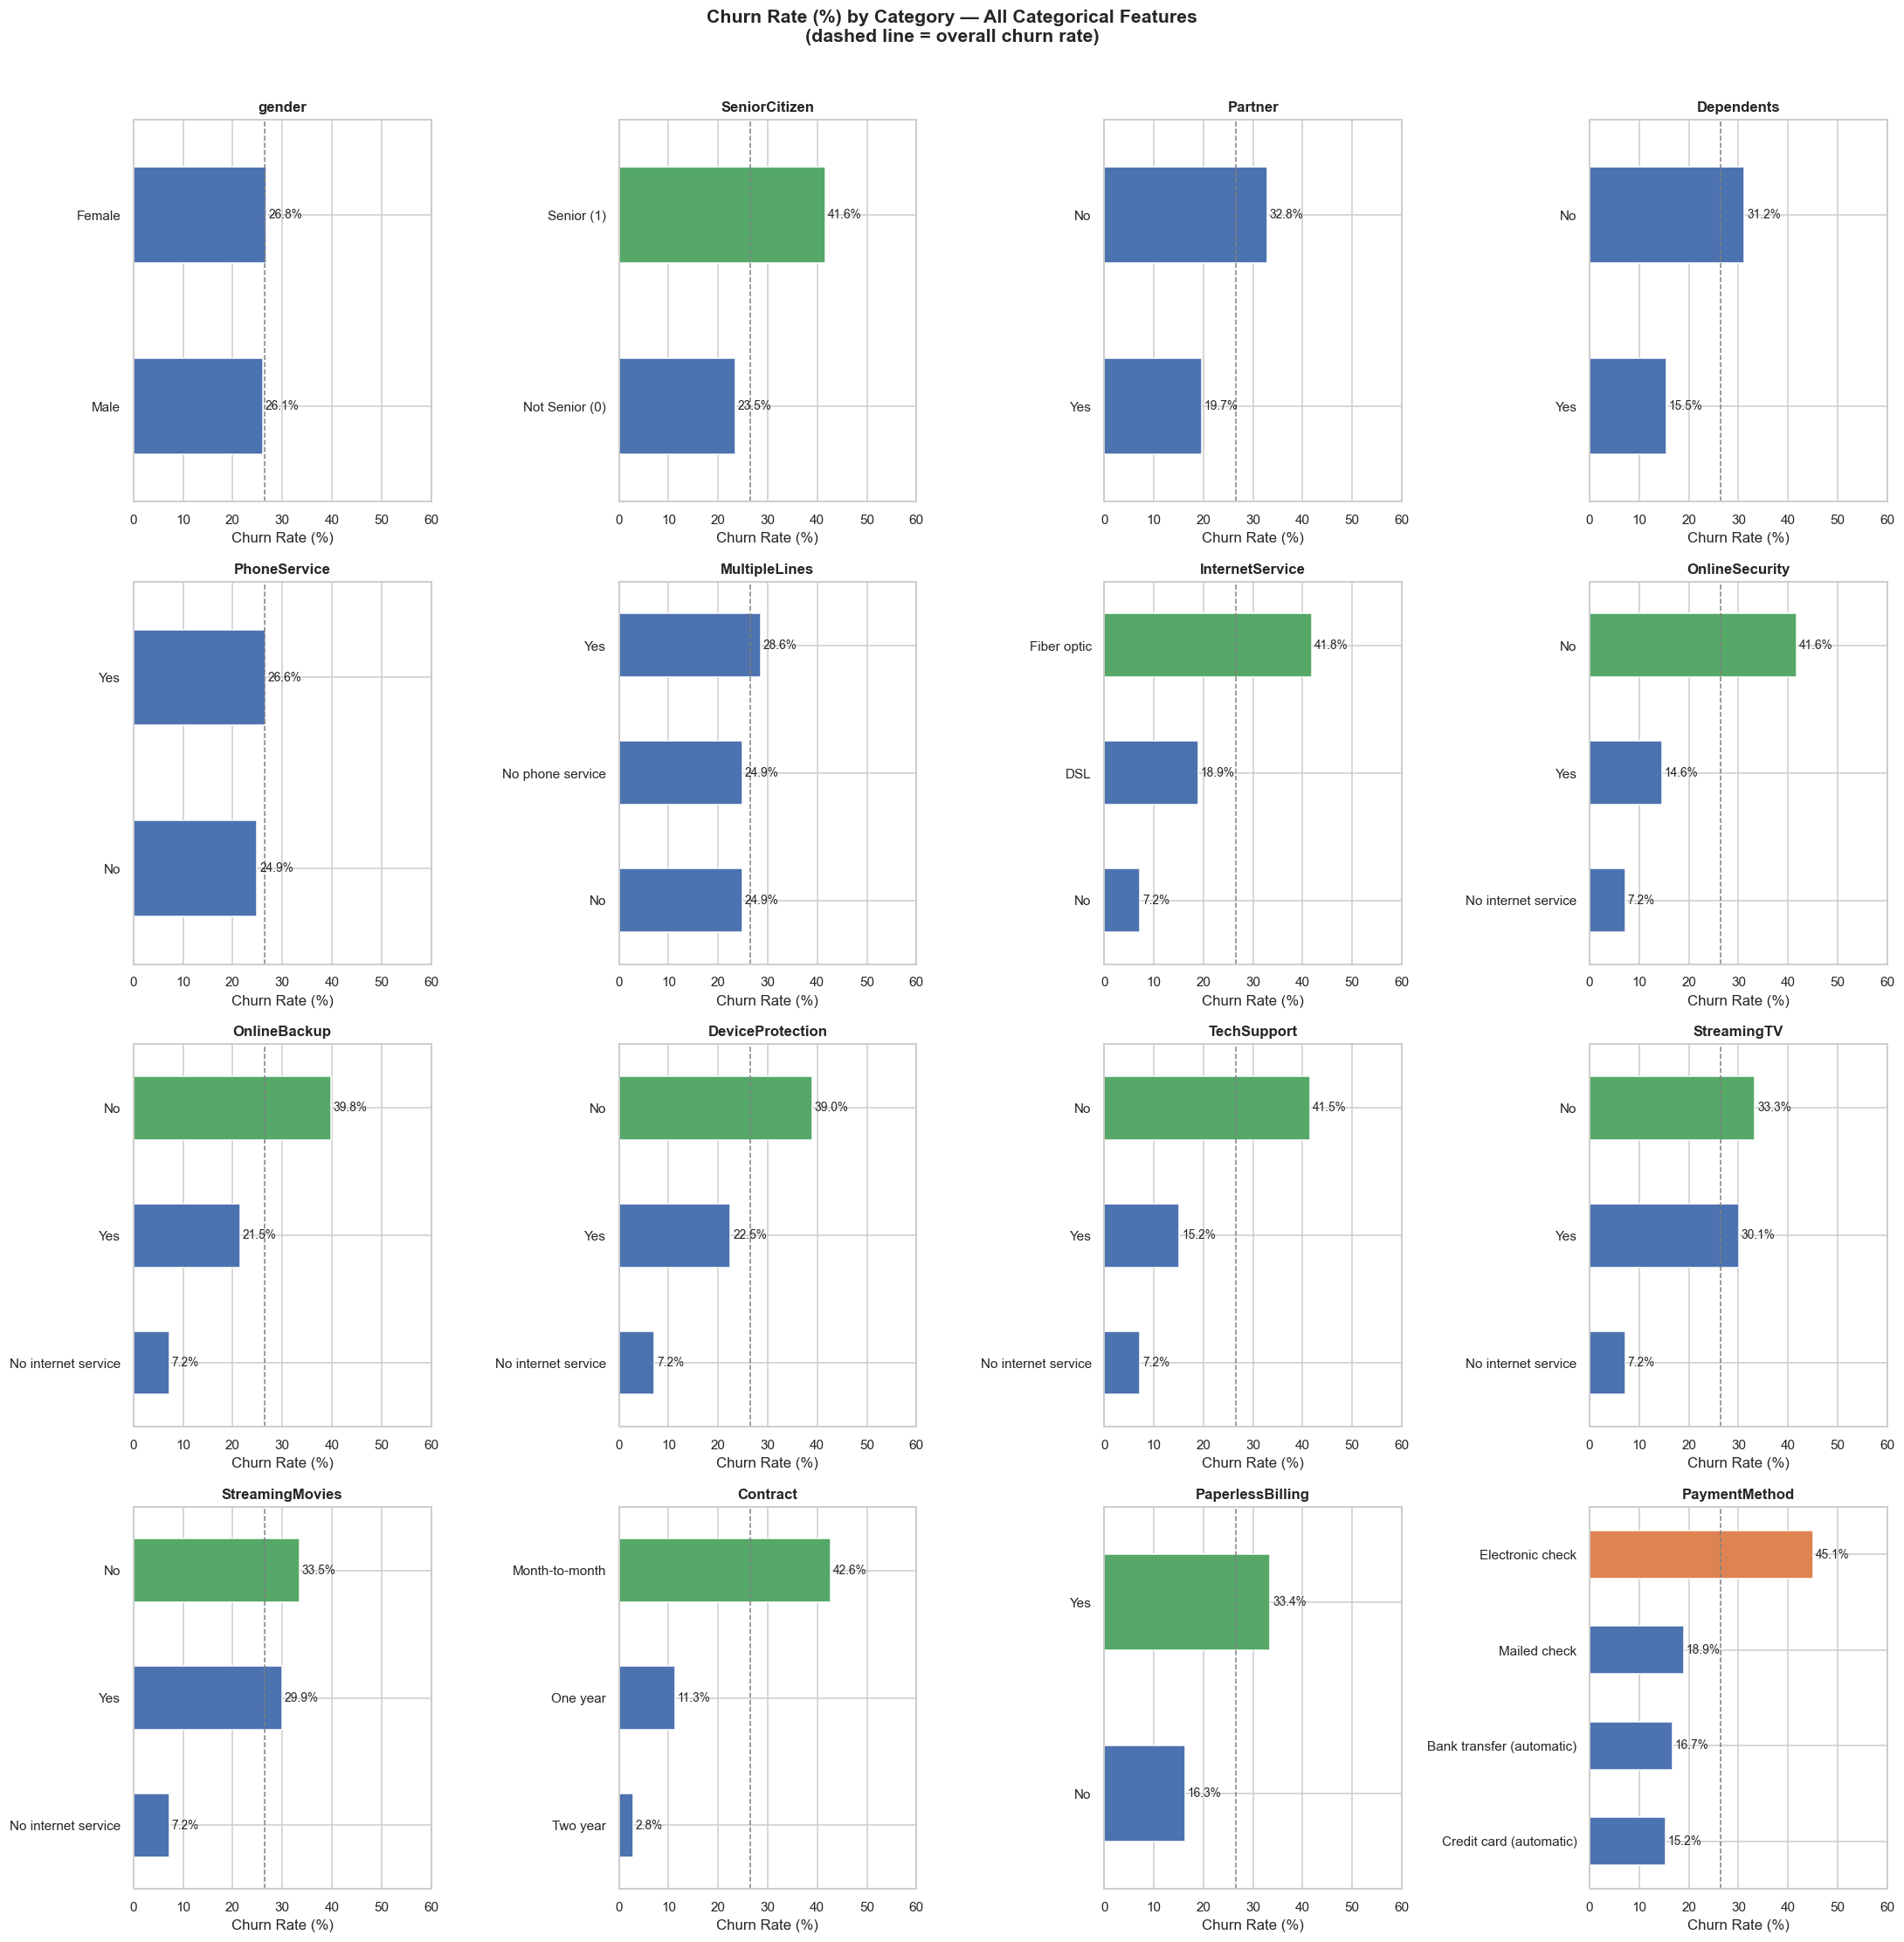

In [33]:
# Categorical columns excluding the target
cat_features = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

# SeniorCitizen is int — map to readable labels for display
df_plot = df.copy()
df_plot['SeniorCitizen'] = df_plot['SeniorCitizen'].map({0: 'Not Senior (0)', 1: 'Senior (1)'})

# Binary churn label for arithmetic
df_plot['Churned'] = (df_plot['Churn'] == 'Yes').astype(int)

fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes_flat = axes.flatten()

for i, col in enumerate(cat_features):
    ax = axes_flat[i]
    churn_rate = (
        df_plot.groupby(col)['Churned']
        .mean()
        .mul(100)
        .sort_values(ascending=True)
    )
    colors_bar = ['#4c72b0' if v < 33 else '#dd8452' if v > 45 else '#55a868'
                  for v in churn_rate.values]
    churn_rate.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white')

    for bar in ax.patches:
        ax.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.1f}%',
            va='center', fontsize=9
        )

    ax.set_title(col, fontweight='bold', fontsize=11)
    ax.set_xlabel('Churn Rate (%)')
    ax.set_ylabel('')
    ax.set_xlim(0, 60)
    ax.axvline(x=df_plot['Churned'].mean() * 100, color='grey', linestyle='--', linewidth=1, label='Overall avg')

# Hide unused subplot
for j in range(len(cat_features), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Churn Rate (%) by Category — All Categorical Features\n(dashed line = overall churn rate)',
             y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:**  
- **Gender**: The churn rate for male and female customers is nearly identical (~26–27%). Gender appears to have minimal association with churn.  
- **SeniorCitizen**: Senior customers (1) show a noticeably higher churn rate (~42%) compared to non-seniors (~24%).  
- **Partner / Dependents**: Customers without a partner or without dependents show higher churn rates. Having household ties may reduce the likelihood of switching providers.  
- **PhoneService**: Minimal difference between customers with and without phone service.  
- **MultipleLines**: Small variation — customers with multiple lines show a slightly higher churn rate.  
- **InternetService**: Fibre optic customers show a substantially higher churn rate (~42%) compared to DSL customers (~19%) and customers with no internet service (~7%). This is one of the strongest signals in the dataset.  
- **OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport**: In each case, customers who have **not** subscribed to the add-on service show higher churn rates compared to those who have — the "No" group consistently outchurns the "Yes" group.  
- **StreamingTV / StreamingMovies**: The difference between subscribers and non-subscribers is small; streaming does not appear to be a strong churn signal.  
- **Contract**: Month-to-month customers churn at a very high rate (~43%), while one-year (~11%) and two-year (~3%) contract customers churn far less. This is the single strongest categorical predictor.  
- **PaperlessBilling**: Customers on paperless billing churn at a higher rate (~34%) than those on paper billing (~17%).  
- **PaymentMethod**: Electronic check payers show the highest churn rate (~45%), while customers on automatic payment methods (bank transfer, credit card) show much lower rates (~16–18%).

---
## 6. Specific Investigations

We now zoom in on the seven feature-churn relationships identified as most important, creating dedicated and more detailed visualisations for each.  
Each sub-section combines a chart with a focused written interpretation.

### 6.1 Churn vs Contract Type

Contract type is widely expected to be the dominant predictor of churn. We visualise both the raw counts and the churn rate to capture the full picture.

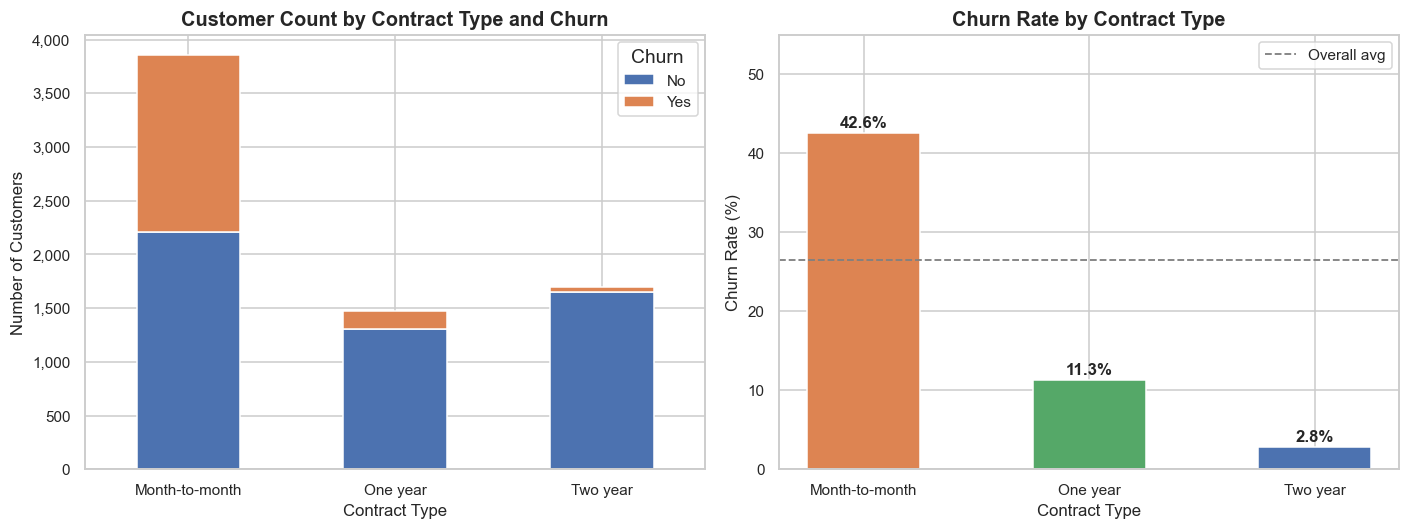

In [34]:
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=False).unstack(fill_value=0)
contract_rate  = (df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean()) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Stacked count bar
contract_churn.plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['#4c72b0', '#dd8452'], edgecolor='white'
)
axes[0].set_title('Customer Count by Contract Type and Churn', fontweight='bold')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=0)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].legend(title='Churn')

# Churn rate bar
contract_rate_ordered = contract_rate.sort_values(ascending=False)
axes[1].bar(contract_rate_ordered.index, contract_rate_ordered.values,
            color=['#dd8452', '#55a868', '#4c72b0'], edgecolor='white', width=0.5)
for i, (label, val) in enumerate(contract_rate_ordered.items()):
    axes[1].text(i, val + 0.7, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].axhline(y=df_plot['Churned'].mean() * 100, color='grey', linestyle='--', linewidth=1.2, label='Overall avg')
axes[1].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[1].set_xlabel('Contract Type')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylim(0, 55)
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretation:**  
Contract type shows the **largest churn rate gap** of any single feature in this dataset.  
- **Month-to-month** customers churn at ~43% — more than four times the dataset average.  
- **One-year** contract customers churn at ~11%.  
- **Two-year** contract customers churn at only ~3%.  

The month-to-month group also represents the majority of customers in the dataset, so it drives a large portion of total churn volume.  
Contract type is strongly associated with churn and is expected to be one of the most important features in any predictive model.

### 6.2 Churn vs Tenure

We examine how churn varies across the full range of customer tenure. A box plot shows quartile differences, and a binned bar chart shows churn rates per tenure bucket to reveal non-linear patterns.

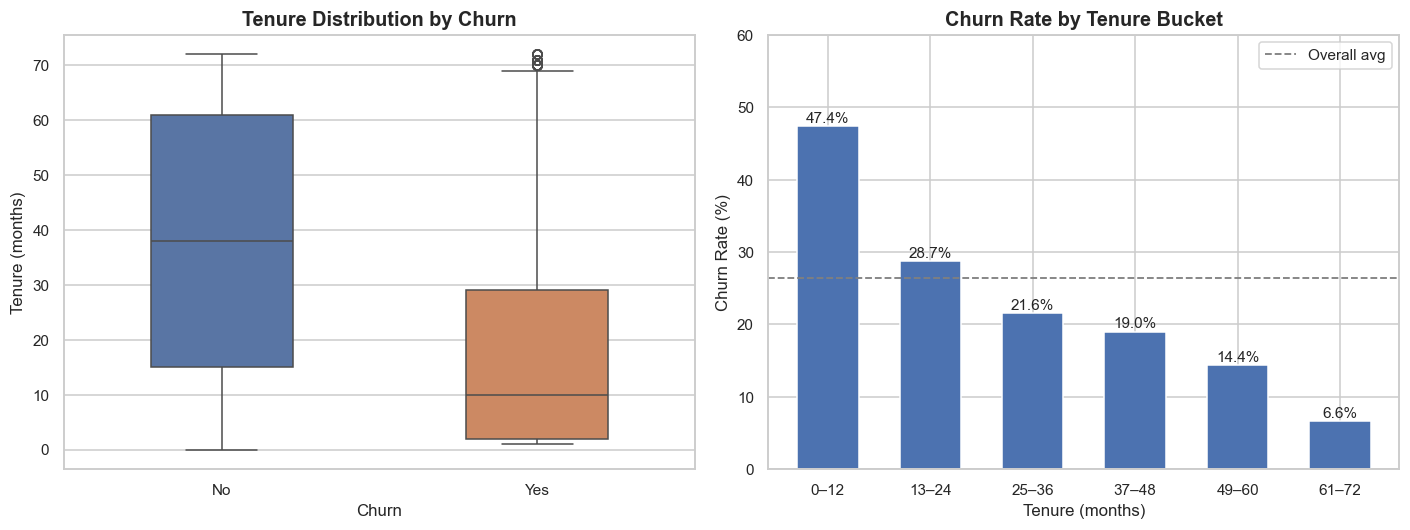

In [35]:
# Bin tenure into 6 roughly equal-width buckets
df_plot['tenure_bin'] = pd.cut(
    df_plot['tenure'],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=['0–12', '13–24', '25–36', '37–48', '49–60', '61–72'],
    include_lowest=True
)

tenure_rate = (df_plot.groupby('tenure_bin', observed=True)['Churned'].mean() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot
sns.boxplot(
    data=df, x='Churn', y='tenure',
    palette={'No': '#4c72b0', 'Yes': '#dd8452'},
    width=0.45, ax=axes[0]
)
axes[0].set_title('Tenure Distribution by Churn', fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Tenure (months)')

# Churn rate by tenure bin
bars = axes[1].bar(tenure_rate.index, tenure_rate.values, color='#4c72b0', edgecolor='white', width=0.6)
for bar in bars:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}%',
        ha='center', fontsize=10
    )
axes[1].axhline(y=df_plot['Churned'].mean() * 100, color='grey', linestyle='--', linewidth=1.2, label='Overall avg')
axes[1].set_title('Churn Rate by Tenure Bucket', fontweight='bold')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 60)
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretation:**  
- Customers who churned have a **median tenure of ~10 months**, whereas retained customers have a median of ~38 months.  
- The binned churn rate drops sharply as tenure increases: customers in the 0–12 month bucket churn at ~48%, while those in the 61–72 month bucket churn at under 10%.  
- This monotone decline suggests a **strong non-linear relationship** — tenure is likely to be one of the most useful numerical features for predicting churn.

### 6.3 Churn vs MonthlyCharges

We use a violin plot (which shows the full distribution shape including multimodality) combined with a binned churn-rate view.

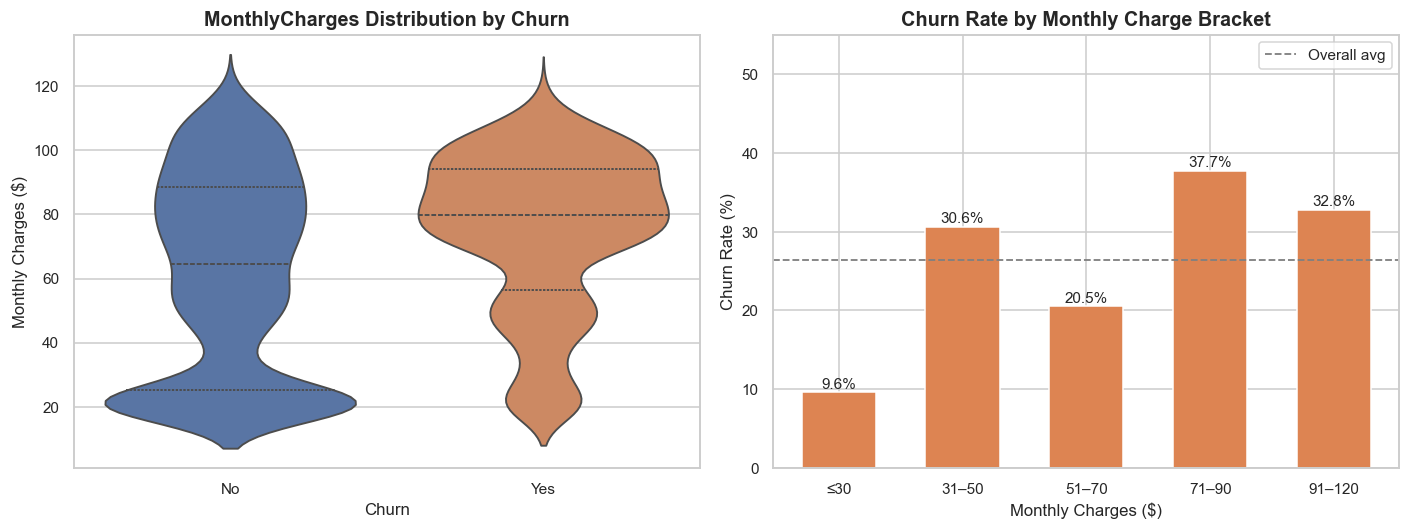

In [36]:
df_plot['charge_bin'] = pd.cut(
    df_plot['MonthlyCharges'],
    bins=[0, 30, 50, 70, 90, 120],
    labels=['≤30', '31–50', '51–70', '71–90', '91–120'],
    include_lowest=True
)

charge_rate = (df_plot.groupby('charge_bin', observed=True)['Churned'].mean() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Violin plot
sns.violinplot(
    data=df, x='Churn', y='MonthlyCharges',
    palette={'No': '#4c72b0', 'Yes': '#dd8452'},
    inner='quartile', ax=axes[0]
)
axes[0].set_title('MonthlyCharges Distribution by Churn', fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Monthly Charges ($)')

# Churn rate by charge bin
bars = axes[1].bar(charge_rate.index, charge_rate.values, color='#dd8452', edgecolor='white', width=0.6)
for bar in bars:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}%',
        ha='center', fontsize=10
    )
axes[1].axhline(y=df_plot['Churned'].mean() * 100, color='grey', linestyle='--', linewidth=1.2, label='Overall avg')
axes[1].set_title('Churn Rate by Monthly Charge Bracket', fontweight='bold')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 55)
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretation:**  
- The violin for `Churn=Yes` is concentrated at **higher monthly charge values** ($60–$100+), while `Churn=No` has a larger mass at lower values.  
- The churn rate increases with monthly charge bracket: customers paying over $90/month churn at ~40%, compared to ~10% for those paying $30 or less.  
- This pattern is consistent with the Fibre optic internet finding — higher-priced plans (often Fibre) are associated with both higher bills and higher churn.

### 6.4 Churn vs Internet Service

Internet service type has three categories: `DSL`, `Fiber optic`, and `No`. We examine both count and churn rate.

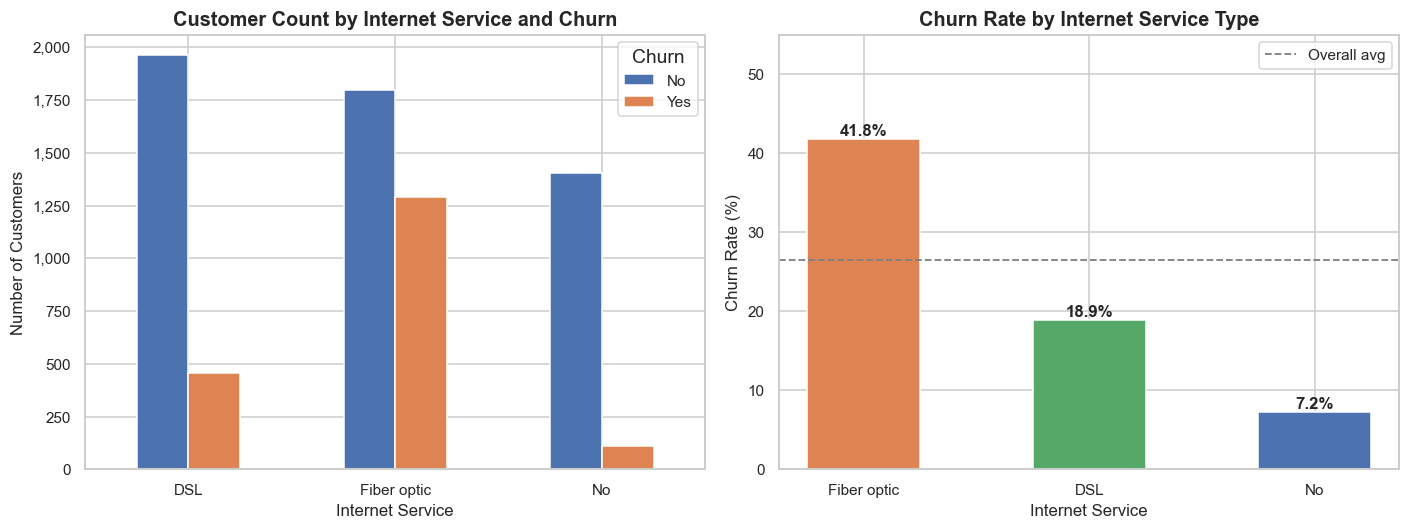

In [37]:
internet_counts = df.groupby('InternetService')['Churn'].value_counts(normalize=False).unstack(fill_value=0)
internet_rate   = (df.groupby('InternetService')['Churn'].apply(lambda x: (x == 'Yes').mean()) * 100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Grouped bar — counts
internet_counts.plot(kind='bar', ax=axes[0], color=['#4c72b0', '#dd8452'], edgecolor='white')
axes[0].set_title('Customer Count by Internet Service and Churn', fontweight='bold')
axes[0].set_xlabel('Internet Service')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=0)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].legend(title='Churn')

# Churn rate
bar_colors = ['#dd8452', '#55a868', '#4c72b0']
axes[1].bar(internet_rate.index, internet_rate.values, color=bar_colors, edgecolor='white', width=0.5)
for i, (label, val) in enumerate(internet_rate.items()):
    axes[1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].axhline(y=df_plot['Churned'].mean() * 100, color='grey', linestyle='--', linewidth=1.2, label='Overall avg')
axes[1].set_title('Churn Rate by Internet Service Type', fontweight='bold')
axes[1].set_xlabel('Internet Service')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 55)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretation:**  
- **Fibre optic** customers churn at ~42% — far above the dataset average of ~26.5%.  
- **DSL** customers churn at ~19%, below average.  
- Customers with **no internet service** churn at only ~7%.  

The fibre optic finding is notable. It may reflect that fibre customers are often on month-to-month contracts, pay higher bills, or experience a mismatch between service expectations and value received. Internet service type is strongly associated with churn and likely interacts with contract type and monthly charges.

### 6.5 Churn vs Payment Method

Payment method has four categories. We investigate whether the method of payment is associated with different churn rates.

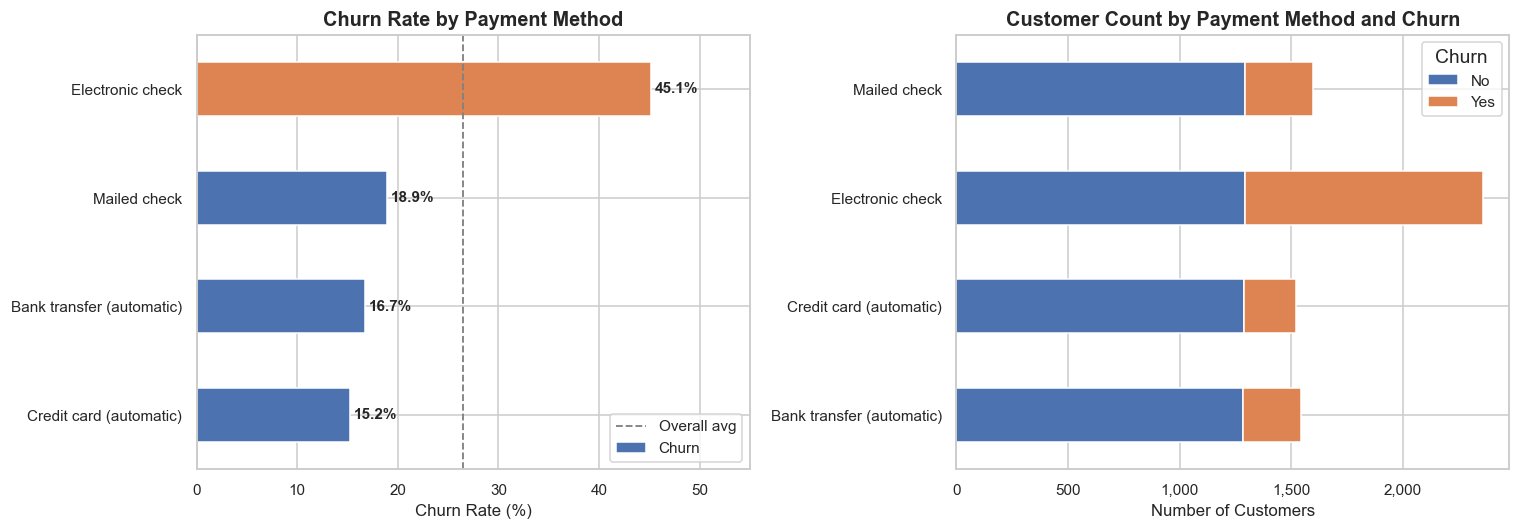

In [38]:
pay_rate = (
    df.groupby('PaymentMethod')['Churn']
    .apply(lambda x: (x == 'Yes').mean())
    .mul(100)
    .sort_values(ascending=True)
)
pay_counts = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=False).unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate — horizontal bar
colors_pay = ['#4c72b0' if v < 26 else '#dd8452' for v in pay_rate.values]
pay_rate.plot(kind='barh', ax=axes[0], color=colors_pay, edgecolor='white')
for bar in axes[0].patches:
    axes[0].text(
        bar.get_width() + 0.4,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.1f}%',
        va='center', fontsize=10, fontweight='bold'
    )
axes[0].axvline(x=df_plot['Churned'].mean() * 100, color='grey', linestyle='--', linewidth=1.2, label='Overall avg')
axes[0].set_title('Churn Rate by Payment Method', fontweight='bold')
axes[0].set_xlabel('Churn Rate (%)')
axes[0].set_ylabel('')
axes[0].set_xlim(0, 55)
axes[0].legend()

# Stacked count
pay_counts.plot(kind='barh', stacked=True, ax=axes[1], color=['#4c72b0', '#dd8452'], edgecolor='white')
axes[1].set_title('Customer Count by Payment Method and Churn', fontweight='bold')
axes[1].set_xlabel('Number of Customers')
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].legend(title='Churn')

plt.tight_layout()
plt.show()

**Interpretation:**  
- **Electronic check** payers churn at ~45% — by far the highest of any payment method and nearly double the overall rate.  
- **Mailed check** payers churn at ~19%.  
- **Bank transfer (automatic)** and **credit card (automatic)** payers churn at ~16–17%.  

The gap between electronic check and automatic payment methods is striking. Customers using electronic checks may be those who do not want to commit to automatic billing (analogous to month-to-month contract preference), or they may skew towards customers who are less satisfied and therefore also more likely to leave. Payment method is associated with churn, though it likely partially overlaps with contract type as a predictor.

### 6.6 Churn vs Tech Support

Tech support is an add-on service (Yes / No / No internet service). We examine whether customers who have enrolled in tech support show different churn behaviour.

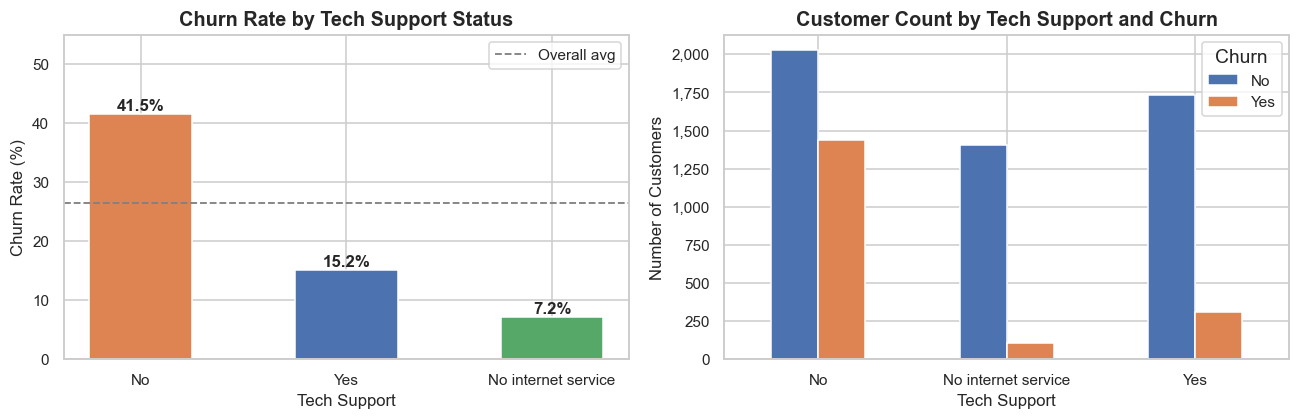

In [39]:
tech_rate   = (
    df.groupby('TechSupport')['Churn']
    .apply(lambda x: (x == 'Yes').mean())
    .mul(100)
    .sort_values(ascending=False)
)
tech_counts = df.groupby('TechSupport')['Churn'].value_counts().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

color_map = {'Yes': '#4c72b0', 'No': '#dd8452', 'No internet service': '#55a868'}
bar_colors = [color_map.get(idx, '#999999') for idx in tech_rate.index]

axes[0].bar(tech_rate.index, tech_rate.values, color=bar_colors, edgecolor='white', width=0.5)
for i, (label, val) in enumerate(tech_rate.items()):
    axes[0].text(i, val + 0.6, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].axhline(y=df_plot['Churned'].mean() * 100, color='grey', linestyle='--', linewidth=1.2, label='Overall avg')
axes[0].set_title('Churn Rate by Tech Support Status', fontweight='bold')
axes[0].set_xlabel('Tech Support')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 55)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend()

tech_counts.plot(kind='bar', ax=axes[1], color=['#4c72b0', '#dd8452'], edgecolor='white')
axes[1].set_title('Customer Count by Tech Support and Churn', fontweight='bold')
axes[1].set_xlabel('Tech Support')
axes[1].set_ylabel('Number of Customers')
axes[1].tick_params(axis='x', rotation=0)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].legend(title='Churn')

plt.tight_layout()
plt.show()

**Interpretation:**  
- Customers who have **not** subscribed to Tech Support churn at ~41% — well above the overall average.  
- Customers who **have** Tech Support churn at only ~15%.  
- Customers with **no internet service** (and therefore no tech support option) churn at ~7%.  

The pattern holds for all similar add-on services (Online Security, Online Backup, Device Protection). Customers who opt into value-added services appear to be more engaged with the provider and thus less likely to churn. Whether the service itself reduces churn, or whether high-satisfaction customers both buy add-ons and stay, cannot be determined from this data alone.

### 6.7 Churn vs Online Security

Online Security follows the same pattern as Tech Support. We include it separately because it is also one of the stronger individual signals among add-on services.

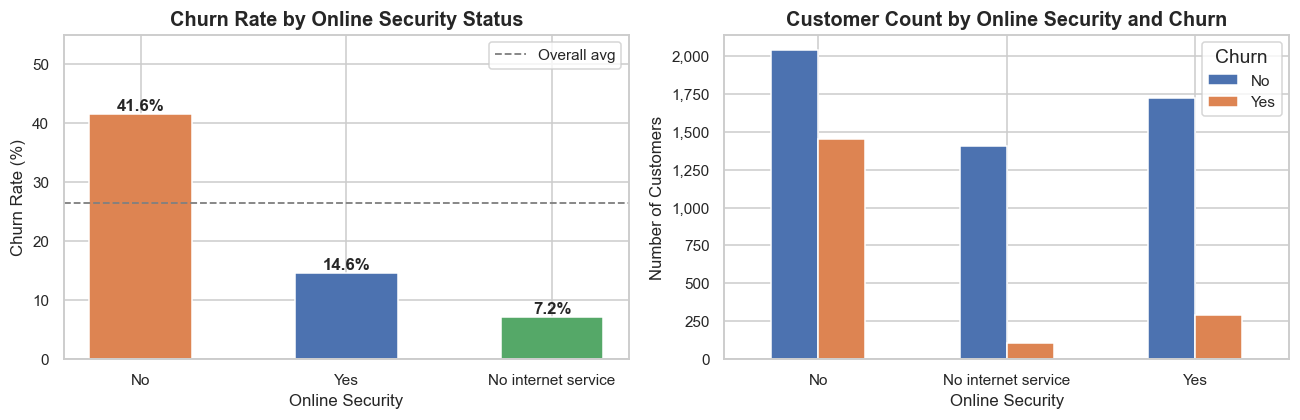

In [40]:
sec_rate   = (
    df.groupby('OnlineSecurity')['Churn']
    .apply(lambda x: (x == 'Yes').mean())
    .mul(100)
    .sort_values(ascending=False)
)
sec_counts = df.groupby('OnlineSecurity')['Churn'].value_counts().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bar_colors_sec = [color_map.get(idx, '#999999') for idx in sec_rate.index]

axes[0].bar(sec_rate.index, sec_rate.values, color=bar_colors_sec, edgecolor='white', width=0.5)
for i, (label, val) in enumerate(sec_rate.items()):
    axes[0].text(i, val + 0.6, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].axhline(y=df_plot['Churned'].mean() * 100, color='grey', linestyle='--', linewidth=1.2, label='Overall avg')
axes[0].set_title('Churn Rate by Online Security Status', fontweight='bold')
axes[0].set_xlabel('Online Security')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 55)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend()

sec_counts.plot(kind='bar', ax=axes[1], color=['#4c72b0', '#dd8452'], edgecolor='white')
axes[1].set_title('Customer Count by Online Security and Churn', fontweight='bold')
axes[1].set_xlabel('Online Security')
axes[1].set_ylabel('Number of Customers')
axes[1].tick_params(axis='x', rotation=0)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].legend(title='Churn')

plt.tight_layout()
plt.show()

**Interpretation:**  
- Customers with **no Online Security** churn at ~42%.  
- Customers with **Online Security** churn at ~15%.  
- The gap is nearly 27 percentage points — the largest of any add-on service.  

Online Security is strongly associated with reduced churn and should be considered an important feature for modelling.

---
## 7. Correlation Analysis

We compute Pearson correlations among all numeric columns: `SeniorCitizen`, `tenure`, `MonthlyCharges`, `TotalCharges`, and the binary-encoded target `Churned` (0/1).  

A correlation heatmap is used to visualise pairwise relationships at a glance.  

**Important caveat:** Pearson correlation measures only *linear* relationships between numeric variables. It does not capture non-linear associations, interactions, or relationships between categorical variables. High correlation between two features also does not mean one causes the other — it means they tend to move together in this dataset.

In [41]:
# Build a numeric-only subset including the binary churn label
df_corr = df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']].copy()
df_corr['Churned'] = (df['Churn'] == 'Yes').astype(int)

corr_matrix = df_corr.corr()

print('=== Correlation matrix ===')
display(corr_matrix.round(3))

=== Correlation matrix ===


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churned
SeniorCitizen,1.000,0.015,0.219,0.102,0.152
tenure,0.015,1.000,0.245,0.826,-0.352
MonthlyCharges,0.219,0.245,1.000,0.651,0.195
TotalCharges,0.102,0.826,0.651,1.000,-0.197
Churned,0.152,-0.352,0.195,-0.197,1.000


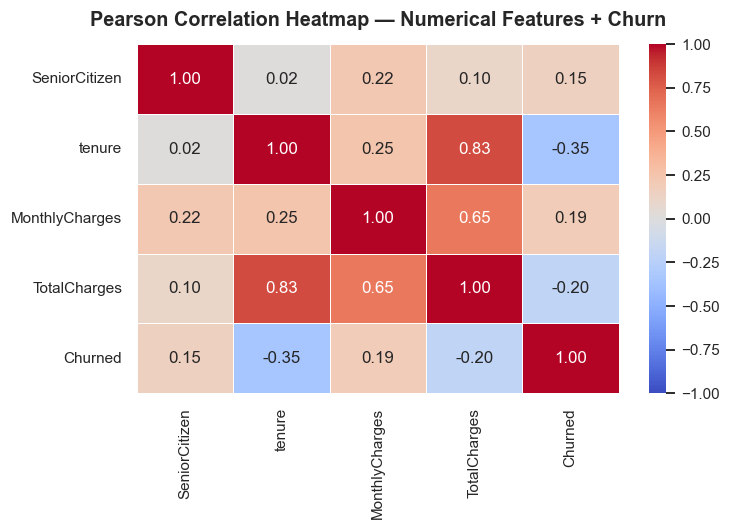

In [42]:
fig, ax = plt.subplots(figsize=(7, 5))

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True   # upper triangle (excluding diagonal)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 11}
)

ax.set_title('Pearson Correlation Heatmap — Numerical Features + Churn',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

**Interpretation:**  

| Pair | Correlation | Note |
|------|-------------|------|
| `tenure` ↔ `TotalCharges` | **+0.83** | Very strong — total charges naturally accumulate over time |
| `MonthlyCharges` ↔ `TotalCharges` | **+0.65** | Moderate-strong — higher bills also drive up total spending |
| `tenure` ↔ `Churned` | **−0.35** | Moderate negative — longer tenure is associated with lower churn |
| `MonthlyCharges` ↔ `Churned` | **+0.19** | Weak positive — higher bills are weakly associated with higher churn |
| `TotalCharges` ↔ `Churned` | **−0.20** | Weak negative — largely driven by tenure (long-tenure customers have high total charges and low churn) |
| `SeniorCitizen` ↔ `Churned` | **+0.15** | Weak positive |

**Key takeaway:** The strong `tenure` ↔ `TotalCharges` correlation (+0.83) signals **multicollinearity** — including both in a linear model simultaneously may inflate variance. A tree-based model handles this naturally; a logistic regression might benefit from dropping one.  

**Reminder:** Correlation ≠ causation. These values reflect statistical co-variation in this particular dataset and should not be interpreted as causal mechanisms.

---
## 8. Key EDA Findings

Based on all plots and statistics above, the following observations stand out as the most important and well-supported findings from this exploratory analysis.  

---

### Finding 1 — Class Imbalance
~73.5% of customers did not churn; ~26.5% did. The dataset is **moderately imbalanced**.  
During modelling, accuracy alone is a poor evaluation metric. AUC-ROC, precision-recall, and F1-score should be used instead.

---

### Finding 2 — Contract type shows the strongest association with churn
Month-to-month customers have a churn rate of ~43%, compared to ~11% for one-year and ~3% for two-year contracts.  
**Contract type is expected to be the single most predictive categorical feature.**

---

### Finding 3 — Tenure shows a strong inverse association with churn
Customers in their first year (0–12 months) churn at ~48%. Customers with 61–72 months tenure churn at under 10%.  
**Churn risk appears highest early in the customer lifecycle**, suggesting that early-stage engagement strategies may be particularly impactful.

---

### Finding 4 — Fibre optic internet service is associated with higher churn
Fibre optic customers churn at ~42%, compared to ~19% for DSL and ~7% for customers with no internet service.  
This may reflect that fibre customers are concentrated on month-to-month contracts or have higher price sensitivity.

---

### Finding 5 — Customers without value-added services show higher churn rates
Across Online Security, Tech Support, Online Backup, and Device Protection, customers who have **not** subscribed show churn rates of 40–42%, while subscribers show churn rates of 14–16%.  
These features appear to be related to churn, though it is not possible from this data alone to determine whether the service itself reduces churn or whether satisfied customers are more likely to subscribe.

---

### Finding 6 — Electronic check payment is associated with elevated churn
Electronic check customers churn at ~45% — the highest rate among payment methods, and nearly three times the rate of customers on automatic payment plans (~16–18%).  
Payment method may partially capture a customer's commitment level or satisfaction with the service.

---

### Finding 7 — Higher MonthlyCharges are associated with higher churn
Customers paying over \$90/month churn at ~40%, compared to ~10% for customers paying \$30 or less.  
This pattern is consistent with the Fibre optic and add-on findings — customers on premium plans (with potentially higher expectations) show a higher observed churn rate.

---

### Finding 8 — Gender shows no meaningful association with churn
Male and female customers churn at nearly identical rates (~26–27%).  
Gender is **unlikely to be a useful predictor** and can be excluded from the feature set without material loss of information.

---
## 9. Questions for Modeling

Based on the EDA, the following features appear potentially useful for predicting churn, grouped by expected importance:

---

### High-signal features (strong association with churn in this EDA)

| Feature | Type | Why it appears important |
|---|---|---|
| `Contract` | Categorical | Largest churn rate gap (~43% vs ~3%); clearly the dominant categorical signal |
| `tenure` | Numerical | Strong inverse association with churn; bimodal distribution with clear separation between churned and retained customers |
| `InternetService` | Categorical | ~22-point gap between Fibre optic and DSL churn rates |
| `OnlineSecurity` | Categorical | ~27-point gap between No and Yes churn rates — strongest add-on signal |
| `TechSupport` | Categorical | ~26-point gap between No and Yes churn rates |
| `PaymentMethod` | Categorical | Electronic check customers churn at ~45%; automatic payment customers at ~16–18% |
| `MonthlyCharges` | Numerical | Churned customers have consistently higher monthly charges |

---

### Moderate-signal features (worth including; contribution may be partial or correlated with high-signal features)

| Feature | Type | Note |
|---|---|---|
| `PaperlessBilling` | Categorical | ~17-point gap; may partially overlap with PaymentMethod |
| `OnlineBackup` | Categorical | Similar pattern to OnlineSecurity |
| `DeviceProtection` | Categorical | Similar pattern to OnlineSecurity |
| `SeniorCitizen` | Numerical (binary) | ~18-point gap; weak-to-moderate linear correlation with churn (+0.15) |
| `Partner` / `Dependents` | Categorical | Customers without household ties show higher churn |
| `TotalCharges` | Numerical | Strongly correlated with `tenure` (r=0.83); may be redundant if tenure is included — consider multicollinearity |

---

### Low-signal features (unlikely to improve model performance)

| Feature | Type | Note |
|---|---|---|
| `gender` | Categorical | Near-zero churn rate difference between groups |
| `PhoneService` | Categorical | Negligible churn rate difference |
| `StreamingTV` / `StreamingMovies` | Categorical | Small churn rate difference; subscribers and non-subscribers behave similarly |
| `MultipleLines` | Categorical | Small and inconsistent signal |

---

### Modeling considerations surfaced by EDA

1. **Multicollinearity:** `tenure` and `TotalCharges` are correlated at r=0.83. In a logistic regression, consider dropping one or using regularisation. Tree-based models handle correlated features naturally.
2. **Class imbalance (~73.5 / 26.5):** Use class-weighted models or SMOTE; evaluate using AUC-ROC and F1-score rather than accuracy.
3. **Non-linear patterns:** Tenure shows a non-linear (monotone decreasing) relationship with churn. Ensemble tree models (Random Forest, XGBoost) will likely capture this better than logistic regression without feature engineering.
4. **Feature interactions:** Internet service type likely interacts with add-on services and monthly charges. A model that can capture interactions (e.g., gradient boosting) may outperform additive models.
5. **Low-signal features:** Gender, PhoneService, and streaming features can be dropped or deprioritised without significant information loss.